In [1]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns


In [111]:
ilya_phi = np.load('ilya_phi.npy').T
ilya_phi.shape

(20, 115064)

In [79]:
from jax import jit
@jit
def entropy_renyi(matrix, power):
    entropies = jnp.sum(matrix ** power, axis=1)
    #return entropies    
    return entropies / jnp.max(entropies)

In [112]:
entropys = [(s, entropy_renyi(ilya_phi, power=s)) for s in np.linspace(1.1, 1.9, num=9)]
counts, bin_edges = jnp.histogram(entropys[0][1], range=(0, 1), bins=10)
counts

Array([1., 7., 5., 3., 2., 0., 1., 0., 0., 1.], dtype=float32)

In [81]:
def plot_distribution_advanced(data, n_bins=20, figsize=(12, 5), 
                              plot_type='all', bandwidth=None):
    """
    Расширенная визуализация распределения.
    
    Args:
        data: 1D массив чисел в [0, 1]
        n_bins: количество бинов для гистограммы
        figsize: размер фигуры
        plot_type: 'hist' | 'kde' | 'ecdf' | 'all'
        bandwidth: ширина окна для KDE (по умолчанию автоматический выбор)
    
    Returns:
        dict с данными для каждого типа графика
    """
    #data = np.asarray(data)
    #n = len(data)
    
    results = {}
    
    # === ГИСТОГРАММА ===
    if plot_type in ['hist', 'all']:
        fig, ax = plt.subplots(figsize=figsize)
        counts, bin_edges, _ = ax.hist(
            data, bins=n_bins, range=(0, 1), density=True,
            color='skyblue', edgecolor='black', alpha=0.7, label='Гистограмма'
        )
        ax.set_xlabel('Значение', fontsize=11)
        ax.set_ylabel('Плотность', fontsize=11)
        ax.set_title('Гистограмма распределения', fontsize=13, pad=15)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xlim(0, 1)
        ax.legend()
        plt.tight_layout()
        plt.show()
        
        results['hist'] = {'counts': counts, 'bin_edges': bin_edges}
    
    # === KDE (ядерная оценка плотности) ===
    if plot_type in ['kde', 'all']:
        from scipy.stats import gaussian_kde
        
        # Автоматический bandwidth, если не задан
        if bandwidth is None:
            bandwidth = 1.06 * data.std() * n ** (-1/5)  # правило Сильвермана
        
        # Оценка плотности
        x_eval = np.linspace(0, 1, 200)
        kde = gaussian_kde(data, bw_method=bandwidth / data.std() if data.std() > 0 else 1.0)
        # Обрезаем выбросы KDE за пределами [0, 1]
        density = kde(x_eval)
        density = np.where((x_eval >= 0) & (x_eval <= 1), density, 0)
        
        plt.figure(figsize=figsize)
        plt.plot(x_eval, density, linewidth=2.5, color='darkorange', label='KDE')
        plt.fill_between(x_eval, density, alpha=0.2, color='darkorange')
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Плотность', fontsize=11)
        plt.title('Ядерная оценка плотности (KDE)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['kde'] = {'x': x_eval, 'density': density}
    
    # === ECDF (эмпирическая функция распределения) ===
    if plot_type in ['ecdf', 'all']:
        n = len(data[0][1])
        
        ecdf = np.arange(1, n + 1) / n
        
        plt.figure(figsize=figsize)
        for i in range(len(data)):
        #for i in range(1):
            sorted_data = np.sort(np.asarray(data[i][1]))
            plt.plot(sorted_data, ecdf, linewidth=2, color='darkgreen', label='ECDF')
        plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Медиана')
        plt.axvline(x=np.median(sorted_data), color='red', linestyle=':', alpha=0.5)
        plt.xlabel('Значение', fontsize=11)
        plt.ylabel('Накопленная доля', fontsize=11)
        plt.title('Эмпирическая функция распределения (ECDF)', fontsize=13, pad=15)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.xlim(0, 1)
        plt.ylim(0, 1.05)
        plt.legend()
        plt.tight_layout()
        plt.show()
        
        results['ecdf'] = {'x': sorted_data, 'ecdf': ecdf}
    
    # Статистика
    #print(f"📊 Статистика данных (n={n})")
    #print(f"   Мин: {data.min():.4f}, Макс: {data.max():.4f}")
    #print(f"   Среднее: {data.mean():.4f}, Медиана: {np.median(data):.4f}")
    #print(f"   Стд. отклонение: {data.std():.4f}")
    #print(f"   Квантили: 25%={np.percentile(data, 25):.4f}, "
    #      f"75%={np.percentile(data, 75):.4f}")
    
    #return results

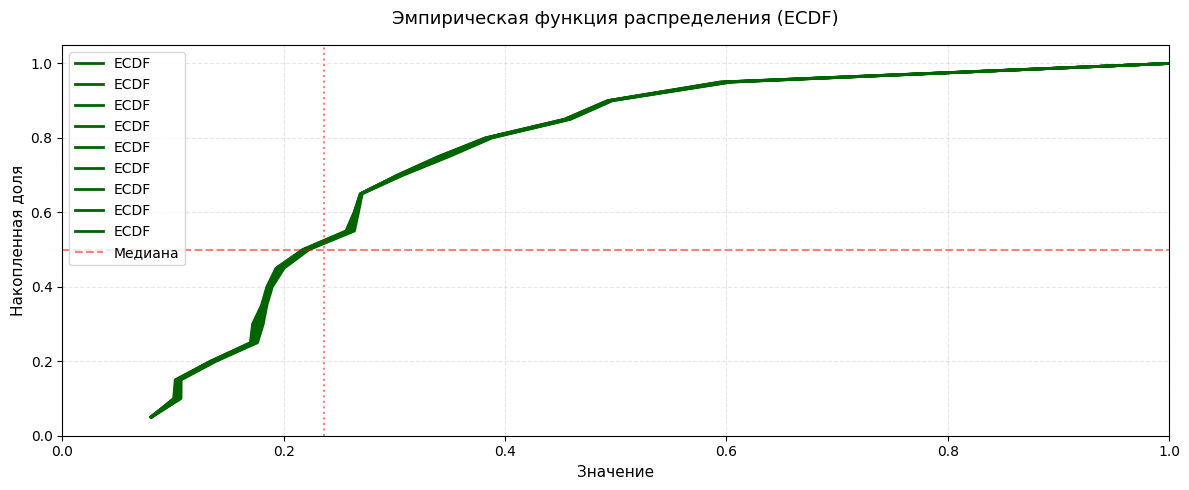

In [113]:
plot_distribution_advanced(entropys, plot_type='ecdf')

In [116]:
import json

with open('ilya_vocab.json', 'r') as file:
    reverse_vocab = json.load(file)

len(reverse_vocab)

115064

In [117]:
vocab = {value: key for key, value in reverse_vocab.items()}

In [118]:
vocab['the']

'98201'

In [105]:
[p for p in ilya_phi[:, int(vocab['the'])]]

[np.float32(0.03263495),
 np.float32(1.6197154e-06),
 np.float32(2.169546e-23),
 np.float32(0.012601097),
 np.float32(0.019396048),
 np.float32(0.00078423554),
 np.float32(1.7684794e-14),
 np.float32(0.003958805),
 np.float32(0.000105620806),
 np.float32(0.019444648),
 np.float32(1.0724022e-09),
 np.float32(0.7035714),
 np.float32(0.0008065288),
 np.float32(0.0419324),
 np.float32(0.053624358),
 np.float32(1.1491047e-09),
 np.float32(2.1584758e-05),
 np.float32(0.057976536),
 np.float32(1.9953916e-07),
 np.float32(0.053139936)]

<BarContainer object of 20 artists>

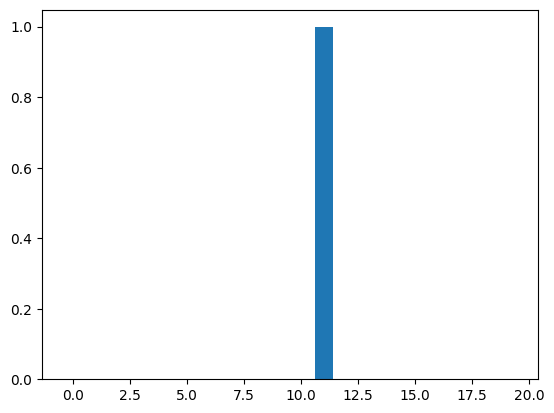

In [114]:
plt.bar(range(20), ilya_phi[:, int(vocab['the'])])

In [92]:
ilya_phi[ilya_phi > 0.99]

array([0.99999994, 0.9996753 , 0.9999999 , ..., 0.99999535, 1.        ,
       0.9966504 ], shape=(95764,), dtype=float32)

In [93]:
mask = (ilya_phi > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = ilya_phi[:, mask]          # выборка столбцов

In [94]:
result.shape

(20, 95764)

In [95]:
cols_idx = np.where(mask)[0]

In [96]:
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95764,))

In [ ]:
[reverse_vocab[str(i)] for i in cols_idx]

## phi hist

In [4]:
import json

with open('phi_hist_vocab.json', 'r') as file:
    vocab = json.load(file)
len(vocab)
reverse_vocab = {value: key for key, value in vocab.items()}

FileNotFoundError: [Errno 2] No such file or directory: 'phi_hist_vocab.json'

In [2]:
phi_hist = np.load('phi_hist.npy').T
phi_hist.shape

(100, 2052, 50)

Text(0.5, 1.0, 'hundred')

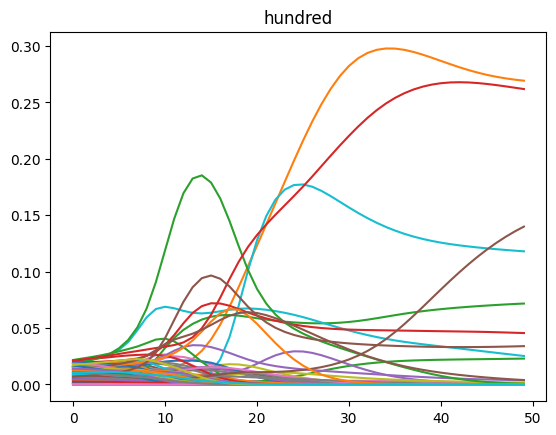

In [9]:
token = 'hundred'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

Text(0.5, 1.0, 'super')

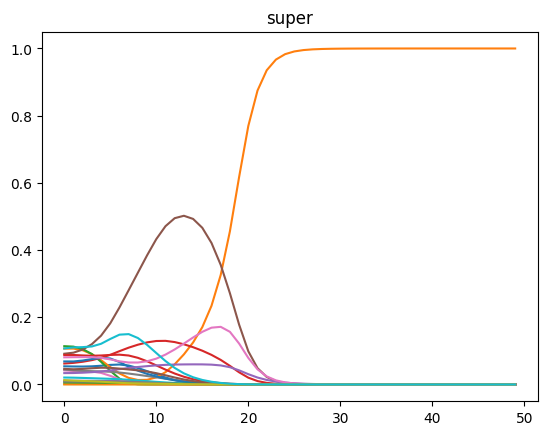

In [170]:
token = 'super'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)

[5.8638316e-33 8.1625375e-20 0.0000000e+00 4.7152620e-28 1.5622051e-29
 4.0739731e-24 0.0000000e+00 7.2167818e-20 3.4064221e-06 4.0946185e-25
 8.7493312e-01 6.1619000e-19 2.0787754e-13 6.9830892e-26 2.3391873e-20
 1.2483741e-01 2.2611898e-04 3.1190416e-25 1.6137779e-08 3.4462321e-22]


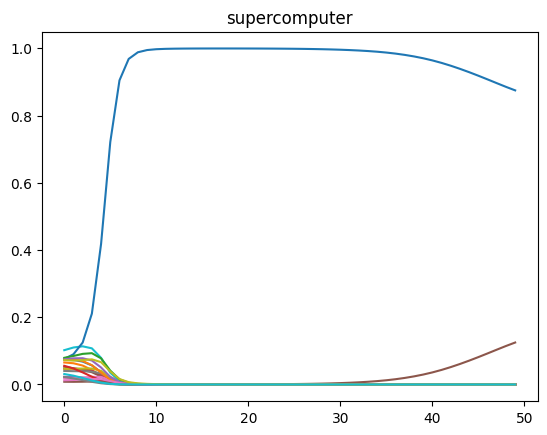

In [203]:
token = 'supercomputer'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

[9.9999988e-01 1.0404790e-34 0.0000000e+00 1.1526705e-31 6.1193036e-21
 3.0218429e-24 0.0000000e+00 5.9565694e-25 0.0000000e+00 1.5287781e-19
 7.0387746e-31 4.3782740e-18 3.7272332e-18 5.2997070e-08 1.5112174e-22
 4.3910945e-36 1.5557137e-29 7.9547648e-09 4.9982635e-39 2.6727180e-19]


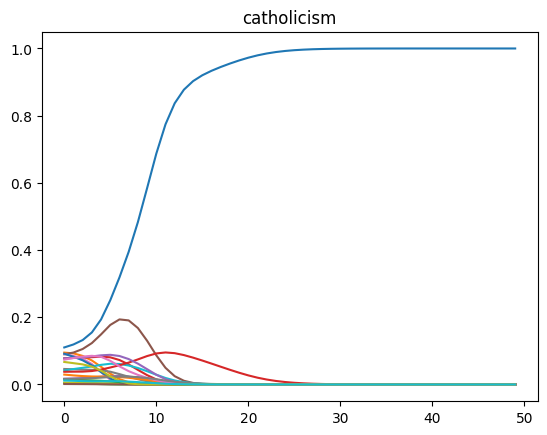

In [202]:
token = 'catholicism'
token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title(token)
print(phi_hist[:, int(vocab[token]), -1])

Text(0.5, 1.0, 'the')

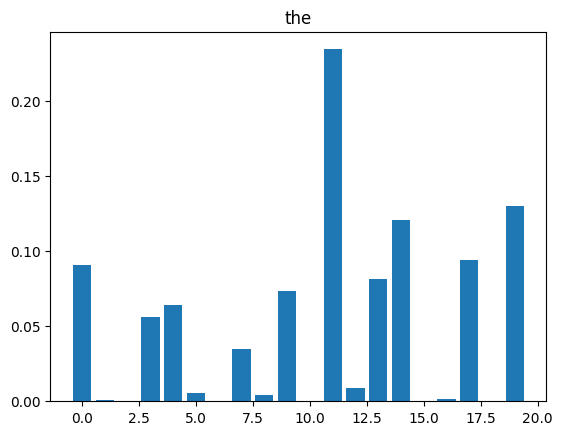

In [197]:
token = 'the'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'super')

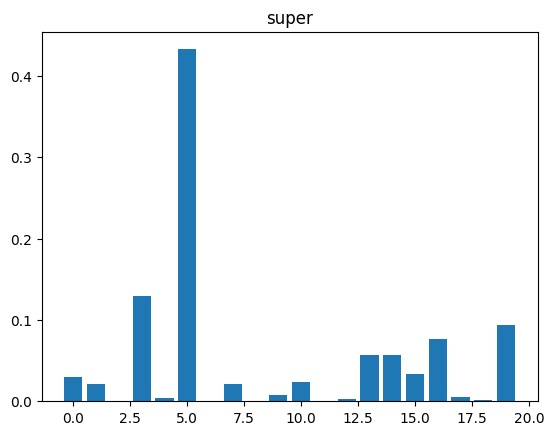

In [199]:
token = 'super'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

Text(0.5, 1.0, 'supercomputer')

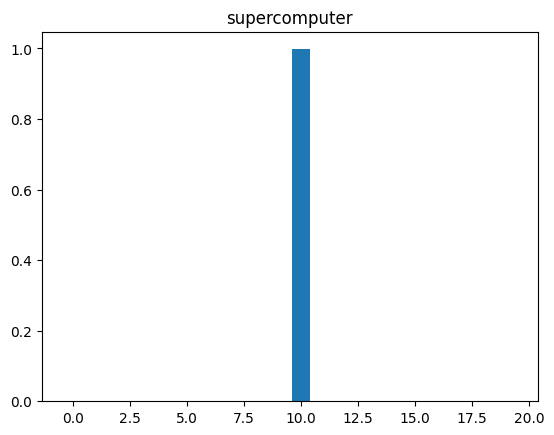

In [198]:
token = 'supercomputer'
plt.bar(range(20), phi_hist[:, int(vocab[token]), 10])
plt.title(token)

In [183]:
np.sum(phi_hist[:, :, -1], axis=1)
plt.bar(range(20), phi_hist[:, int(vocab['supercomputer']), 10])

array([ 6716.2603,  5183.4604,  1550.1204,  3549.8696,  5072.6025,
        2072.4297, 19100.52  ,  5127.8203,  7443.3047,  2674.2751,
       11594.847 ,  3505.0474,  3644.2246,  3395.1553,  4283.7974,
        9514.928 ,  5906.6733,  3856.6052,  8796.604 ,  2075.1763],
      dtype=float32)

In [187]:
mask = (phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = phi_hist[:, mask, -1]         # выборка столбцов
result.shape

(20, 95763)

In [189]:
cols_idx = np.where(mask)[0]
cols_idx

array([     0,      2,      3, ..., 115061, 115062, 115063],
      shape=(95763,))

Text(0.5, 1.0, 'Распределение якорных слов по темам')

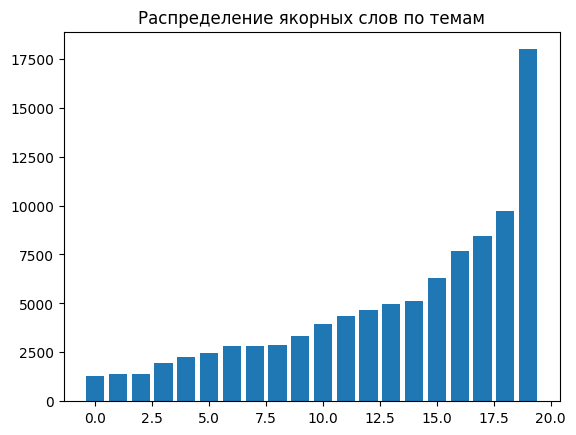

In [193]:
plt.bar(range(20), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

# Сравнение всего корпуса и фильтрованного

In [5]:
import json

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in vocab.items()}

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=115064
len(filtered_vocab)=30668


In [6]:
all_phi_hist = np.load('all_phi_hist.npy').T
filtered_phi_hist = np.load('filtered_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 115064, 50)
filtered_phi_hist.shape=(100, 30668, 50)


[0.00000000e+00 0.00000000e+00 1.37791015e-30 0.00000000e+00
 4.94907298e-20 0.00000000e+00 0.00000000e+00 9.25302931e-28
 0.00000000e+00 2.39240128e-38 0.00000000e+00 8.42947448e-38
 4.01250824e-32 5.01120375e-28 5.79832438e-25 3.34080902e-22
 3.93851109e-29 8.72005323e-19 2.09964092e-34 0.00000000e+00
 0.00000000e+00 0.00000000e+00 2.02520285e-26 7.33882674e-25
 0.00000000e+00 1.15964217e-34 1.51585882e-27 0.00000000e+00
 0.00000000e+00 2.64494629e-24 3.31192192e-11 0.00000000e+00
 0.00000000e+00 2.77878273e-23 1.90055570e-20 2.60803028e-38
 2.80743739e-25 8.96112408e-30 1.05822412e-28 3.27570423e-26
 5.53551065e-38 0.00000000e+00 1.92995961e-26 1.11473916e-12
 0.00000000e+00 4.05620077e-31 0.00000000e+00 7.29316422e-24
 3.58168634e-28 1.07248336e-27 1.77653953e-23 2.56915010e-27
 2.82463319e-38 2.83006693e-34 7.83476727e-29 1.40236361e-34
 1.86806976e-24 3.51135121e-09 3.45977301e-33 5.17938744e-23
 9.05666845e-22 1.47626233e-39 1.39105991e-31 5.38921599e-22
 8.75794232e-01 0.000000

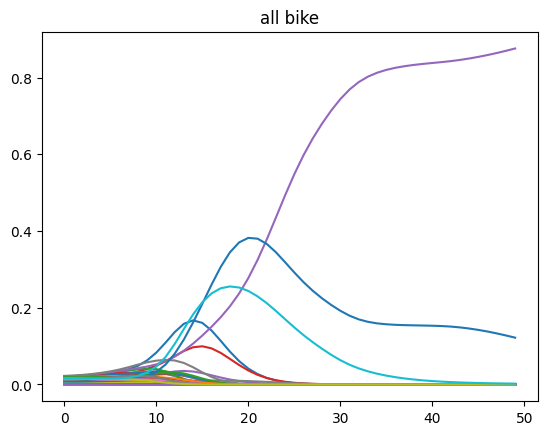

In [35]:
token = 'bike'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[5.39502092e-02 3.07434976e-16 1.56665713e-18 7.65962369e-27
 2.58107545e-18 1.54203210e-22 5.10665787e-10 4.30545051e-14
 9.97037319e-35 1.14960758e-05 1.82811333e-17 5.59137362e-25
 2.93510426e-15 5.98563421e-11 3.36812274e-03 1.19873894e-11
 9.06445001e-20 9.21362361e-11 5.04000617e-12 1.56555532e-18
 6.25324608e-28 2.47675127e-11 8.64613394e-13 4.92733458e-13
 1.92559135e-10 3.92404276e-14 6.60015931e-11 3.14064964e-23
 1.80864546e-10 1.10390612e-11 8.93081290e-13 3.84917951e-18
 4.91835034e-14 8.84109734e-13 9.26181393e-18 1.65746761e-15
 2.08540295e-15 1.76234548e-12 2.21833267e-13 1.51519040e-11
 1.14514691e-08 1.40588002e-26 9.28843807e-12 2.53651203e-23
 7.44688084e-26 1.21500776e-25 1.80405192e-24 3.40582120e-12
 2.79153262e-23 8.84343434e-13 1.36046817e-17 3.18511439e-13
 8.79937169e-23 1.02334113e-10 2.07751686e-14 4.69089052e-08
 5.51005797e-10 5.57868552e-16 9.22770026e-14 2.96053209e-16
 3.43033891e-12 3.11549388e-06 4.68018356e-24 1.01795846e-11
 2.68502801e-19 1.182487

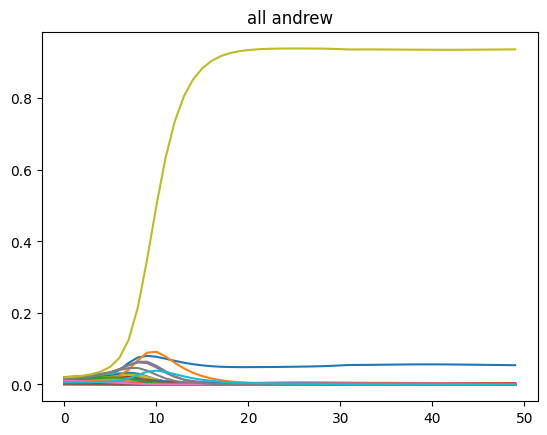

In [9]:
token = 'andrew'
token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('all ' + token)
print(all_phi_hist[:, int(all_vocab[token]), -1])

[1.48867494e-22 0.00000000e+00 3.47018233e-30 6.86976503e-30
 1.68773203e-32 3.42724063e-02 0.00000000e+00 0.00000000e+00
 0.00000000e+00 8.38130286e-29 5.55523707e-20 6.15160045e-25
 3.59633864e-29 1.95790495e-08 0.00000000e+00 0.00000000e+00
 3.72008930e-18 7.38432443e-40 2.04362961e-17 6.47821724e-01
 0.00000000e+00 1.70103988e-33 3.04617881e-23 2.09644760e-39
 6.00276813e-02 0.00000000e+00 1.69582932e-37 0.00000000e+00
 1.67432346e-32 2.73722364e-33 1.27030456e-10 8.37364548e-30
 2.03928066e-33 2.77076415e-27 2.07105019e-38 6.83214512e-21
 3.29439682e-36 1.16649129e-39 3.54757620e-33 7.85649823e-34
 4.80148629e-31 4.58132225e-19 1.22609005e-38 5.43494117e-14
 2.68493691e-33 3.70118568e-13 0.00000000e+00 9.27443806e-35
 9.56054664e-31 0.00000000e+00 2.06641934e-33 1.77545932e-14
 4.03721957e-03 2.16174688e-15 0.00000000e+00 3.27078323e-28
 1.06112854e-26 2.51979922e-25 1.27335304e-24 6.39277965e-40
 1.93027438e-30 4.77772754e-29 4.29253583e-25 5.04627619e-27
 7.92958703e-15 1.389086

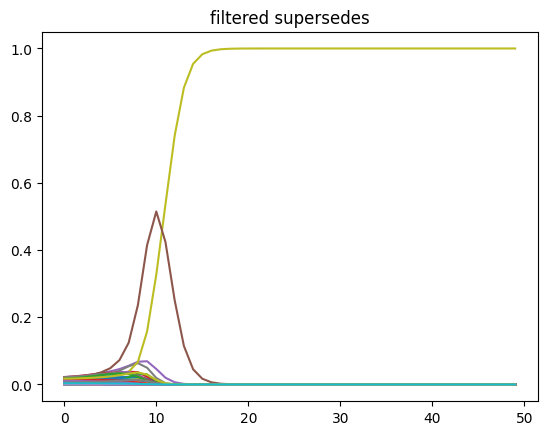

In [10]:
token = 'supersedes'
token_hist = [p for p in all_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(token_hist)):
    plt.plot(token_hist[i])
plt.title('filtered ' + token)
print(filtered_phi_hist[:, int(filtered_vocab[token]), -1])

In [12]:
[k for k in filtered_vocab if k.startswith('super')]

['super',
 'superb',
 'superbowl',
 'superceded',
 'supercharged',
 'supercharging',
 'supercomputer',
 'supercomputing',
 'superconducting',
 'superdrives',
 'superficial',
 'supergas',
 'superhighway',
 'superhighways',
 'superhuman',
 'superior',
 'superiority',
 'supermac',
 'superman',
 'supermarket',
 'supermen',
 'supernatural',
 'supernet',
 'supernova',
 'superseded',
 'supersedes',
 'superset',
 'supersonic',
 'superstar',
 'superstars',
 'superstition',
 'superuser',
 'supervga',
 'supervised',
 'supervision',
 'supervisor']

In [28]:
ilya_phi = np.load('all_phi_hist.npy').T
ilya_phi.shape

(100, 115064, 50)

## Сравнение all и filtered

In [108]:
import json

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(all_vocab)=}")
print(f"{len(filtered_vocab)=}")

len(all_vocab)=115064
len(filtered_vocab)=30668


In [109]:
all_phi_hist = np.load('all_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")
filtered_phi_hist = np.load('filtered_phi_hist.npy').T
print(f"{filtered_phi_hist.shape=}")

all_phi_hist.shape=(100, 115064, 50)
filtered_phi_hist.shape=(100, 30668, 50)


Text(0.5, 1.0, 'filtered good')

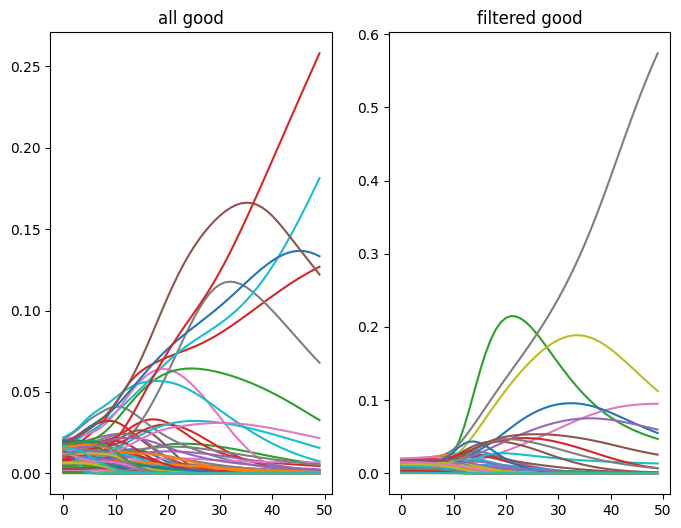

In [4]:
token = 'good'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


Text(0.5, 1.0, 'filtered bad')

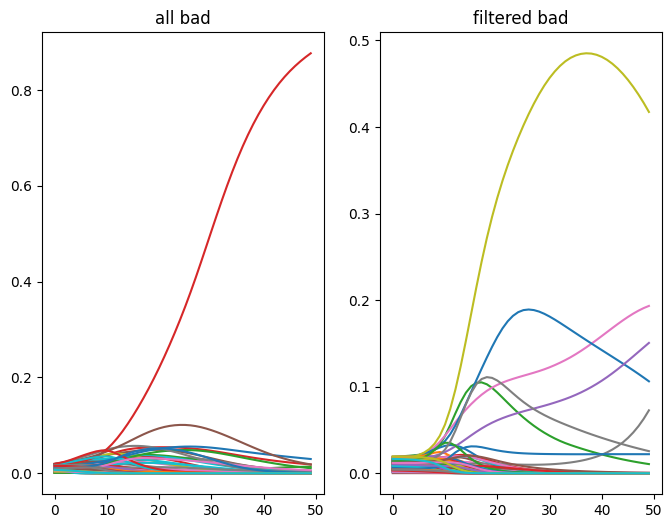

In [5]:
token = 'bad'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

all_token_hist = [p for p in all_phi_hist[:, int(all_vocab[token]), :]]
for i in range(len(all_token_hist)):
    ax1.plot(all_token_hist[i])
ax1.set_title('all ' + token)

filtered_token_hist = [p for p in filtered_phi_hist[:, int(filtered_vocab[token]), :]]
for i in range(len(filtered_token_hist)):
    ax2.plot(filtered_token_hist[i])
ax2.set_title('filtered ' + token)


In [ ]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
motorcycles_anchors = anchors_tfidf['rec.motorcycles']
motorcycles_anchors_ids = [all_vocab[anchor] for anchor in motorcycles_anchors]
sum_topics_motorcycles = np.sum(all_phi_hist[:, motorcycles_anchors_ids, -1], axis=1)
sum_topics_motorcycles[sum_topics_motorcycles > 0.5]

array([ 0.5723363 , 16.471954  ,  1.9189036 ,  1.        ,  2.91711   ,
        0.51553863,  0.7073983 ], dtype=float32)

In [6]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
space_anchors = anchors_tfidf['sci.space']
space_anchors_ids = [all_vocab[anchor] for anchor in space_anchors]
sum_space_topics = np.sum(all_phi_hist[:, space_anchors_ids, -1], axis=1)
sum_space_topics[sum_space_topics > .5]

array([2.6314013, 2.6575103, 1.8760339, 1.6493521, 0.5270725, 8.040634 ,
       1.1841917, 1.1108165], dtype=float32)

In [7]:
with open('20ng_anchors_tfidf.json', 'r') as file:
    anchors_tfidf = json.load(file)
mac_anchors = anchors_tfidf['comp.sys.mac.hardware']
mac_anchors_ids = [all_vocab[anchor] for anchor in mac_anchors]
sum_mac_topics = np.sum(all_phi_hist[:, mac_anchors_ids, -1], axis=1)
sum_mac_topics[sum_mac_topics > .5]

array([1.995627  , 1.        , 1.        , 0.90133756, 1.1775292 ,
       0.5322305 , 7.3794928 , 1.        , 5.7225122 ], dtype=float32)

In [9]:
mask = (all_phi_hist[:, :, -1] > 0.99).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = all_phi_hist[:, mask, -1]         # выборка столбцов
print(f"{result.shape=}")
print(f"{all_phi_hist.shape=}")

cols_idx = np.where(mask)[0]
print(f"{cols_idx=}")


result.shape=(100, 35641)
all_phi_hist.shape=(100, 115064, 50)
cols_idx=array([     3,      4,      6, ..., 115058, 115060, 115062],
      shape=(35641,))


Text(0.5, 1.0, 'Распределение якорных слов по темам')

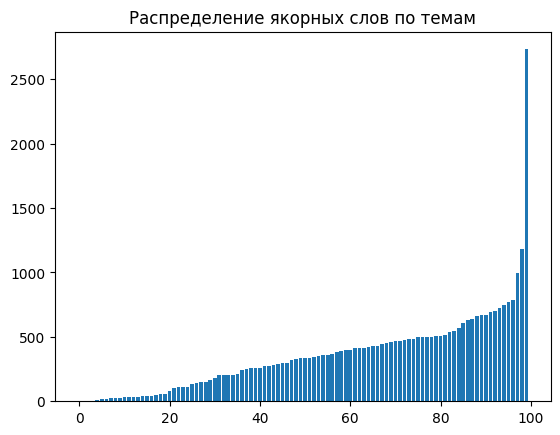

In [10]:
plt.bar(range(100), np.sort(np.sum(result, axis=1)))
plt.title("Распределение якорных слов по темам")

# Сравнение для bike и space

In [22]:
full_20newsgroups = fetch_20newsgroups(data_home='./data/', subset='all')
data = full_20newsgroups.data

In [80]:
filtered_phi_hist = np.load('filtered_phi_hist.npy').T
print(f"{filtered_phi_hist.shape=}")

with open('filtered_phi_hist_vocab.json', 'r') as file:
    filtered_vocab = json.load(file)
    filtered_reverse_vocab = {value: key for key, value in filtered_vocab.items()}

print(f"{len(filtered_vocab)=}")

filtered_phi_hist.shape=(100, 30668, 50)
len(filtered_vocab)=30668


In [81]:
all_phi_hist = np.load('all_phi_hist.npy').T
print(f"{all_phi_hist.shape=}")

with open('all_phi_hist_vocab.json', 'r') as file:
    all_vocab = json.load(file)
    all_reverse_vocab = {value: key for key, value in all_vocab.items()}

print(f"{len(all_vocab)=}")

all_phi_hist.shape=(100, 115064, 50)
len(all_vocab)=115064


In [17]:
threshold = 1e-6

phi_bike = filtered_phi_hist[:, filtered_vocab['bike'], -1] # последняя phi колонка для токена bike
phi_bike[phi_bike < threshold] = 0 # зануляем все малые значения
print(phi_bike) # темы с достаточно большой вероятностью
bike_topic = np.where(phi_bike == 1)
bike_mask = (filtered_phi_hist[bike_topic, :, -1] == 1.0)
bike_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(bike_mask)]
bike_anchors

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.8041934  0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.19580624 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


[]

In [18]:
threshold = 1e-4

phi_space = filtered_phi_hist[:, filtered_vocab['rocketry'], -1] # распределение по темам
phi_space[phi_space < threshold] = 0
print(phi_space)
space_topic = np.where(phi_space > 1 - threshold) # тема, в которой это слово якорь
space_mask = (filtered_phi_hist[space_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(space_mask)
space_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(space_mask)] # слова, которые потенциально якорные в этой теме
space_anchors

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.27277297 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.7272269  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


[]

In [27]:
threshold = 1e-4

phi_christian = filtered_phi_hist[:, filtered_vocab['archbishop'], -1] # распределение по темам
phi_christian[phi_christian < threshold] = 0
print(phi_christian)
christian_topic = np.where(phi_christian > 1 - threshold) # тема, в которой это слово якорь
christian_mask = (filtered_phi_hist[christian_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(christian_mask)
christian_anchors = [filtered_reverse_vocab[i] for i in np.flatnonzero(christian_mask)] # слова, которые потенциально якорные в этой теме
christian_anchors

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.99998146 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]


['abdel',
 'adherence',
 'anticipating',
 'archbishop',
 'baritone',
 'chant',
 'concerts',
 'constituencies',
 'counties',
 'deficit',
 'democracies',
 'faire',
 'grandiose',
 'grievances',
 'infusion',
 'inmates',
 'irrespective',
 'laissez',
 'legalization',
 'lui',
 'maneuver',
 'melodramatic',
 'meme',
 'ministers',
 'optimism',
 'pamphlets',
 'resemble',
 'riyadh',
 'rolfe',
 'saudi',
 'slimy',
 'spewing',
 'squalor',
 'stockman',
 'supervision',
 'tenor',
 'torches',
 'ukraine',
 'unemployment',
 'unites',
 'unwittingly',
 'viz']

In [ ]:
[k for k in filtered_vocab if k.startswith('schi')]

['schilling', 'schism', 'schizophrenia']

In [23]:
docs_with_token = set()
for anchor in christian_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))


731


In [25]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'talk.politics.misc': 101,
         'talk.politics.mideast': 98,
         'sci.space': 87,
         'sci.crypt': 63,
         'sci.med': 54,
         'rec.sport.baseball': 50,
         'alt.atheism': 45,
         'soc.religion.christian': 36,
         'talk.politics.guns': 29,
         'rec.sport.hockey': 28,
         'rec.autos': 26,
         'talk.religion.misc': 21,
         'sci.electronics': 15,
         'misc.forsale': 13,
         'comp.os.ms-windows.misc': 12,
         'comp.sys.ibm.pc.hardware': 11,
         'comp.windows.x': 11,
         'comp.graphics': 11,
         'rec.motorcycles': 11,
         'comp.sys.mac.hardware': 9})

In [ ]:
Надо взять слова с равномерным распределением по темам
Посмотреть на темы с самым большим количеством якорных слов

Array([26995, 20006, 26993,  5025,  2106, 27200, 20836, 26998, 13210,
        2406,  1511, 18684, 18149, 17181, 14808, 14071, 14071, 18684,
       18149, 17181, 28296, 14808, 26157,  6910,  5320,  9739, 27793,
        5496,  1884, 19320,  5078,  9739,  1928, 19108,  9739, 17191,
        1734,  1120, 17474,  1734, 22132,  9739, 22830,  7375, 13775,
       12405, 21641, 21781, 10341, 22566, 17669, 22830,  7375, 19174,
       27026, 19108, 13775, 21834, 22132, 25189,  6280, 18360, 30612,
        7376, 13776, 26995, 20006, 26993,  5025, 25750,  7541,  1277],      dtype=int32)

In [ ]:
data[7527: 7528]

["From: naren@tekig1.PEN.TEK.COM (Naren Bala)\nSubject: Re: Theists posting\nOrganization: Tektronix, Inc., Beaverton,  OR.\nLines: 21\n\nIn article <C4ux99.AIC@ra.nrl.navy.mil> khan@itd.itd.nrl.navy.mil (Umar Khan) writes:\n\nStuff deleted \n\n>Is there a concordance for the FAQ?  WHich translation is considered\n>most authoritative?  Is there an orthodox commentary for the FAQ\n>available?  Is there one FAQ for militant atheists and another for\n>moderate atheists; or, do you all read from the same FAQ?  If so,\n>how do you resolve differences of interpretation?\n\nHmmmmmmmmmmmm.............................................         \nI can put the same question to followers of any religion. How do you\nMoslems resolve differences of opinion ?? Don't tell me that there\nis one interpretation of the Quran. Read the soc.culture.* newsgroups.\nYou will zillions of different interpretations.\n\n-- Naren\nnaren@TEKIG1.PEN.TEK.COM \n\nAll standard disclaimers apply\n\n"]

In [ ]:
filtered_vocab['mmmmmmmmmm']

17438

In [ ]:
filtered_reverse_vocab[12405]

'hmmmmmmmmmmmm'

In [42]:
threshold = 1e-4

phi_christian = all_phi_hist[:, all_vocab['archbishop'], -1] # распределение по темам
phi_christian[phi_christian < threshold] = 0
print(phi_christian)
christian_topic = np.where(phi_christian > 1 - threshold) # тема, в которой это слово якорь
christian_mask = (all_phi_hist[christian_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(christian_mask)
christian_anchors = [all_reverse_vocab[i] for i in np.flatnonzero(christian_mask)] # слова, которые потенциально якорные в этой теме
christian_anchors

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]


['acclimate',
 'actuelles',
 'afafter',
 'afflicting',
 'aghast',
 'airboxes',
 'aluminized',
 'anatomists',
 'archbishop',
 'archishop',
 'arian',
 'attain',
 'avoide',
 'berryh',
 'bicephalous',
 'bishop',
 'blackbird',
 'blobs',
 'blur',
 'boiler',
 'boilers',
 'boils',
 'bracelet',
 'bruise',
 'bubbles',
 'byzantine',
 'campos',
 'caricature',
 'cathedra',
 'catholique',
 'cavitate',
 'cavitation',
 'cecil',
 'cerebral',
 'chich',
 'chord',
 'christological',
 'christology',
 'cinnci',
 'circulates',
 'coal',
 'coldest',
 'commencement',
 'committe',
 'concelebrated',
 'condensate',
 'condense',
 'condenser',
 'condensers',
 'condensing',
 'confect',
 'confer',
 'conferral',
 'conformed',
 'congar',
 'conjoined',
 'consecrate',
 'consecrates',
 'consecrating',
 'consecrations',
 'contamininats',
 'coptic',
 'courrier',
 'crud',
 'curving',
 'daunting',
 'degue',
 'delictis',
 'departure',
 'deploying',
 'dictionnaire',
 'differed',
 'dinh',
 'disobedience',
 'disobedient',
 'disobe

In [23]:
docs_with_token = set()
for anchor in christian_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))


731


In [25]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'talk.politics.misc': 101,
         'talk.politics.mideast': 98,
         'sci.space': 87,
         'sci.crypt': 63,
         'sci.med': 54,
         'rec.sport.baseball': 50,
         'alt.atheism': 45,
         'soc.religion.christian': 36,
         'talk.politics.guns': 29,
         'rec.sport.hockey': 28,
         'rec.autos': 26,
         'talk.religion.misc': 21,
         'sci.electronics': 15,
         'misc.forsale': 13,
         'comp.os.ms-windows.misc': 12,
         'comp.sys.ibm.pc.hardware': 11,
         'comp.windows.x': 11,
         'comp.graphics': 11,
         'rec.motorcycles': 11,
         'comp.sys.mac.hardware': 9})

In [49]:
threshold = 1e-4

phi_bike = all_phi_hist[:, all_vocab['bike'], -1] # распределение по темам
phi_bike[phi_bike < threshold] = 0
print(phi_bike)
bike_topic = np.argmax(phi_bike) # тема, в которой это слово больше всех
bike_mask = (all_phi_hist[bike_topic, :, -1] > 1 - threshold) # маска для слов, которые потенциально якорные в этой теме
#print(bike_mask)
bike_anchors = [all_reverse_vocab[i] for i in np.flatnonzero(bike_mask)] # слова, которые потенциально якорные в этой теме
bike_anchors

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.87579423 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.12199949 0.         0.         0.         0.         0.
 0.         0.         0.         0.00220629]


['abd',
 'aboce',
 'adman',
 'aerostich',
 'aggresive',
 'alcala',
 'andr',
 'ara',
 'arax',
 'armenienne',
 'armenische',
 'arrevola',
 'astute',
 'atp',
 'backrest',
 'bading',
 'banaian',
 'banked',
 'barbie',
 'barclay',
 'barreling',
 'bathed',
 'battalion',
 'beest',
 'belasco',
 'bem',
 'berkian',
 'beziehungen',
 'blinding',
 'buffeting',
 'buttocks',
 'caltrans',
 'camber',
 'caneven',
 'canteens',
 'capmgtsci',
 'circumci',
 'coasted',
 'coburn',
 'coburnn',
 'compasses',
 'controvery',
 'corded',
 'counteracting',
 'countersteer',
 'countersteered',
 'counties',
 'crosswind',
 'degress',
 'deleta',
 'derich',
 'derichc',
 'derounian',
 'desales',
 'deteriorating',
 'deutsch',
 'displaced',
 'dissappear',
 'diverge',
 'doders',
 'donelan',
 'doping',
 'dowdy',
 'effectivly',
 'elbows',
 'electrics',
 'encouch',
 'enno',
 'erick',
 'fairing',
 'finesse',
 'firstgear',
 'fja',
 'flashers',
 'fleece',
 'footrest',
 'forested',
 'forking',
 'freeways',
 'fringed',
 'fundesco',
 '

In [48]:
bike_topic = np.argmax(phi_bike) 
bike_topic
phi_bike[bike_topic]

np.float32(0.87579423)

In [50]:
docs_with_token = set()
for anchor in bike_anchors:
  #docs_with_token = [(i, t) for i, t in enumerate(data) if anchor in t.lower()]
  docs_with_token.update({i for i, t in enumerate(data) if anchor in t.lower()})

print(len(docs_with_token))

5656


In [51]:
from collections import Counter
counts = Counter([full_20newsgroups.target_names[full_20newsgroups.target[doc]] for doc in docs_with_token])
counts

Counter({'talk.politics.mideast': 580,
         'soc.religion.christian': 377,
         'rec.sport.hockey': 371,
         'rec.motorcycles': 334,
         'talk.politics.guns': 321,
         'rec.autos': 309,
         'sci.crypt': 299,
         'sci.space': 297,
         'sci.med': 280,
         'talk.politics.misc': 278,
         'comp.windows.x': 258,
         'rec.sport.baseball': 254,
         'sci.electronics': 247,
         'comp.graphics': 237,
         'misc.forsale': 230,
         'alt.atheism': 229,
         'comp.os.ms-windows.misc': 203,
         'comp.sys.mac.hardware': 188,
         'talk.religion.misc': 184,
         'comp.sys.ibm.pc.hardware': 180})

In [89]:
last_all_phi = all_phi_hist[:, :, -1]
last_all_phi.shape

(100, 115064)

In [76]:
beforelast_all_phi = all_phi_hist[:, :, -1]
mask = (beforelast_all_phi == 1)
np.sum(mask)
#np.sum(all_phi_hist[all_phi_hist == 1], axis=2)

np.int64(24957)

In [79]:
threshold = 0 # 1e-4
#np.sum(last_all_phi > 1 - threshold)
mask = (last_all_phi == 1)#.any(axis=0)
print(np.sum(mask))
topic_ids = set(np.where(mask)[0])
token_ids = set(np.where(mask)[1])
len(token_ids)
#[all_reverse_vocab[i] for i in token_ids]


24957


24957

In [ ]:
mask = (last_all_phi == 1).any(axis=0)  # True для столбцов, содержащих хотя бы одну 1
result = all_phi_hist[:, mask, -1]         # выборка столбцов
print(f"{result.shape=}")
print(f"{all_phi_hist.shape=}")

cols_idx = np.where(mask)[0]
print(f"{cols_idx=}")

In [92]:
sum_last = np.sum(last_all_phi, axis=0)

In [98]:
last_all_phi.shape

(100, 115064)

In [101]:
np.sum(last_all_phi, axis=0)

array([0.9999999 , 0.99999994, 0.99999994, ..., 0.        , 1.        ,
       0.        ], shape=(115064,), dtype=float32)

In [102]:
first_all_phi = all_phi_hist[:, :, 1]

In [103]:
sum_first = np.sum(first_all_phi, axis=0)

In [107]:
np.sum(sum_first > 0.99)

np.int64(58503)

In [116]:
last_all_phi = all_phi_hist[:, :, -1]
sum_phi = np.sum(last_all_phi, axis=0)
np.sum(sum_phi == 0)

np.int64(56561)

In [ ]:
last_all_phi = all_phi_hist[:, :, -1]
sum_phi = np.sum(last_all_phi, axis=0)
np.sum(sum_phi == 0)

In [117]:
all_phi_hist.shape

(100, 115064, 50)

In [118]:
for i in range(50):
    last_all_phi = all_phi_hist[:, :, i]
    sum_phi = np.sum(last_all_phi, axis=0)
    print(i, np.sum(sum_phi == 0))

0 56561
1 56561
2 56561
3 56561
4 56561
5 56561
6 56561
7 56561
8 56561
9 56561
10 56561
11 56561
12 56561
13 56561
14 56561
15 56561
16 56561
17 56561
18 56561
19 56561
20 56561
21 56561
22 56561
23 56561
24 56561
25 56561
26 56561
27 56561
28 56561
29 56561
30 56561
31 56561
32 56561
33 56561
34 56561
35 56561
36 56561
37 56561
38 56561
39 56561
40 56561
41 56561
42 56561
43 56561
44 56561
45 56561
46 56561
47 56561
48 56561
49 56561
